# 🌍 Global Energy & Economic Impact Analysis (1990–2018)


##  Problem Statement

Energy consumption and economic growth are deeply connected. 
Countries like India, China, and the United States have experienced rapid industrialization and economic expansion over the past decades.


## Objectives

This project aims to:

• Compare energy consumption trends across the United States, China, and India  
• Examine the relationship between GDP and greenhouse gas emissions  
• Analyze renewable energy growth over time  
• Calculate energy consumption per capita  
• Perform correlation analysis on key economic and environmental variables

<br>

##  Tools & Technologies

The following Python libraries are used in this project:

- **Pandas** -> Data cleaning and manipulation
- **NumPy** -> Numerical and statistical analysis
- **Matplotlib** -> Data visualization

## Dataset Source

The dataset used in this analysis is the Global Energy Dataset obtained from public energy statistics databases. 
It includes information on GDP, population, energy consumption, renewable energy, and greenhouse gas emissions.

The analysis focuses on three countries:
• United States
• China
• India

The study period covers 1990–2018.

<br>



##  Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Loading The DataSet

In [2]:
df=pd.read_csv('world_data.csv')

In [3]:
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


<br>

## Exploring The DataSet

Before performing any analysis, it is important to understand the structure of the dataset.
We examine:
- Number of rows and columns
- Column names
- Data types
- Sample records

In [4]:
df.shape

(22012, 129)

<br>

In [5]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=129)

<br>`

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.7+ MB


<br>

In [7]:
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,22012.000000,1.812300e+04,1.111300e+04,1747.000000,2687.000000,2302.000000,2767.000000,5275.000000,5527.000000,5492.000000,...,6849.000000,4035.000000,2413.000000,4639.000000,4744.000000,7065.000000,7996.000000,4065.000000,6886.000000,4101.000000
mean,1974.213247,1.053096e+08,3.585114e+11,46.091694,2.719074,133.558459,38.068209,64.716800,10.966685,1.954035,...,0.622750,0.210395,267.541206,7.314174,53.422938,62.811828,17.561153,232.108949,1.404910,0.651413
std,35.058653,4.640460e+08,2.411179e+12,274.616745,10.057018,264.707851,111.623148,201.043915,47.953561,5.274155,...,2.066186,0.643304,5940.944120,37.327922,273.255306,252.734217,101.693172,733.841324,4.489043,1.893820
min,1900.000000,1.833000e+03,1.642060e+08,-100.000000,-50.843000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-51.208000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1946.000000,1.712404e+06,1.365898e+10,-0.616500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.029000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1984.000000,6.991543e+06,4.167411e+10,8.179000,0.000000,15.482000,0.673000,0.146000,0.010000,0.062000,...,0.000000,0.000000,20.000000,0.000000,0.005000,0.000000,0.000000,0.051000,0.000000,0.003000
75%,2003.000000,2.557688e+07,1.744295e+11,26.508500,0.861500,165.266750,13.629500,34.289000,0.690000,1.577500,...,0.095000,0.018500,47.971000,0.315000,2.357750,2.101000,0.140000,45.523000,0.372000,0.268000
max,2022.000000,7.975105e+09,1.136302e+14,5659.328000,141.131000,2588.512000,1199.207000,2514.102000,677.570000,71.429000,...,40.000000,7.586000,242384.844000,665.413000,5487.600000,3219.852000,2139.230000,8422.012000,56.840000,26.157000


<br>

##  Selecting Relevant Columns

The dataset contains more than 100 variables related to energy production, consumption, and emissions. 
For this analysis, we will select only the columns that are relevant to our study.

In [8]:
columns_needed = [ "country", "year","population","gdp","primary_energy_consumption","coal_consumption","oil_consumption","gas_consumption",
                   "solar_consumption","wind_consumption", "renewables_consumption","greenhouse_gas_emissions"]

df = df[columns_needed]

df.head()

,country,year,population,gdp,primary_energy_consumption,coal_consumption,oil_consumption,gas_consumption,solar_consumption,wind_consumption,renewables_consumption,greenhouse_gas_emissions
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.41
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,198.34
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,213.80
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,229.70
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,252.61


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     22012 non-null  object 
 1   year                        22012 non-null  int64  
 2   population                  18123 non-null  float64
 3   gdp                         11113 non-null  float64
 4   primary_energy_consumption  12588 non-null  float64
 5   coal_consumption            5420 non-null   float64
 6   oil_consumption             5713 non-null   float64
 7   gas_consumption             5215 non-null   float64
 8   solar_consumption           4683 non-null   float64
 9   wind_consumption            4744 non-null   float64
 10  renewables_consumption      5479 non-null   float64
 11  greenhouse_gas_emissions    5306 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 2.0+ MB


<br>

<br>

In [10]:
df.isnull().sum()

country                           0
year                              0
population                     3889
gdp                           10899
primary_energy_consumption     9424
coal_consumption              16592
oil_consumption               16299
gas_consumption               16797
solar_consumption             17329
wind_consumption              17268
renewables_consumption        16533
greenhouse_gas_emissions      16706
dtype: int64

##  Data Cleaning

Real-world datasets often contain missing values.
These missing values can occur because:

- Some countries did not record certain data
- Some energy sources were not available in earlier years
- Data collection methods varied over time

Before performing analysis, we need to handle missing values
to ensure accurate results.

In [11]:
df.shape

(22012, 12)

In [12]:
e_columns = ["primary_energy_consumption","coal_consumption","oil_consumption","gas_consumption","solar_consumption","wind_consumption",
                  "renewables_consumption"]

df.loc[:, e_columns] = df[e_columns].fillna(0)

In [13]:
df = df.dropna(subset=["population", "gdp"])

In [14]:
df.isnull().sum()

country                          0
year                             0
population                       0
gdp                              0
primary_energy_consumption       0
coal_consumption                 0
oil_consumption                  0
gas_consumption                  0
solar_consumption                0
wind_consumption                 0
renewables_consumption           0
greenhouse_gas_emissions      7951
dtype: int64

In [15]:
countries = ["India", "China", "United States"]

df_2 = df[df["country"].isin(countries)]

We focus on India, China, and the United States 
to compare emerging and developed economies.

In [16]:
df_2["country"].unique()

array(['China', 'India', 'United States'], dtype=object)

In [17]:
df_2.shape

(320, 12)

<br>

<br>

##  Feature Engineering

Feature engineering involves creating new variables from existing datato extract deeper insights.
In this section we create two important metrics:
1. **Energy Per Capita**
   - Measures average energy consumption per person.
2. **Renewable Energy Share**
   - Measures the percentage of energy coming from renewable sources such as solar and wind.

<br>

In [18]:
df_2 = df_2[df_2["year"] >= 1990]

In [19]:
df_2.loc[:,"energy_per_capita"] = df_2["primary_energy_consumption"] / df_2["population"]

In [20]:
df_2[["country","year","energy_per_capita"]].head()

,country,year,energy_per_capita
4373,China,1990,0.000007
4374,China,1991,0.000007
4375,China,1992,0.000007
4376,China,1993,0.000008
4377,China,1994,0.000008


In [21]:
df_2.loc[:,"renewable_share"] = df_2["renewables_consumption"] /df_2["primary_energy_consumption"]

In [22]:
df_2[["country","year","renewable_share"]].head()

,country,year,renewable_share
4373,China,1990,0.047237
4374,China,1991,0.044248
4375,China,1992,0.044127
4376,China,1993,0.047579
4377,China,1994,0.049525


In [23]:
#  Recalculating Energy per Capita to a readable scale (Multiplied by 1,000,000)
df_2.loc[:, "energy_per_capita"] = (df_2["primary_energy_consumption"] / df_2["population"]) * 1000000

#  Recalculating Renewable Share as a Percentage (Multiply by 100)
df_2.loc[:, "renewable_share"] = (df_2["renewables_consumption"] / df_2["primary_energy_consumption"]) * 100

In [24]:
df_2[["country", "year", "energy_per_capita", "renewable_share"]].head()

,country,year,energy_per_capita,renewable_share
4373,China,1990,6.880662,4.723674
4374,China,1991,7.122351,4.424781
4375,China,1992,7.411395,4.412707
4376,China,1993,7.908675,4.757860
4377,China,1994,8.323468,4.952476


In [25]:
df_2.shape

(87, 14)

In [26]:
df_2.head()

,country,year,population,gdp,primary_energy_consumption,coal_consumption,oil_consumption,gas_consumption,solar_consumption,wind_consumption,renewables_consumption,greenhouse_gas_emissions,energy_per_capita,renewable_share
4373,China,1990,1.153704e+09,3.385122e+12,7938.249,6134.517,1274.572,154.183,0.006,0.006,374.977,NaN,6.880662,4.723674
4374,China,1991,1.170626e+09,3.508948e+12,8337.610,6433.427,1379.144,156.118,0.006,0.027,368.921,NaN,7.122351,4.424781
4375,China,1992,1.183813e+09,3.755037e+12,8773.708,6731.497,1495.912,159.142,0.009,0.388,387.158,NaN,7.411395,4.412707
4376,China,1993,1.195856e+09,4.126170e+12,9457.634,7170.356,1663.776,168.969,0.012,0.627,449.981,NaN,7.908675,4.757860
4377,China,1994,1.207287e+09,4.438753e+12,10048.812,7641.667,1690.638,176.971,0.015,1.135,497.665,NaN,8.323468,4.952476


<br>

<br>

In [27]:
df_2[["energy_per_capita","renewable_share"]].describe()

,energy_per_capita,renewable_share
count,87.000000,87.000000
mean,35.720901,6.555139
std,37.378770,1.912388
min,2.643110,3.421370
25%,5.342159,5.011561
50%,14.272745,6.570890
75%,81.050634,7.528134
max,93.999863,12.861612


### Summary Statistics

This table shows the distribution of energy consumption per capita and renewable energy share.

- **Mean** represents the average value across all countries and years.
- **Min / Max** show the range of the dataset.
- **Standard deviation** indicates how much variation exists.

These statistics provide a high-level understanding of global energy consumption patterns.

In [28]:
top_energy = df_2.groupby("country")
top_energy=top_energy["energy_per_capita"].mean().sort_values(ascending=False).head(10)

top_energy

country
United States    87.348257
China            15.592866
India             4.221580
Name: energy_per_capita, dtype: float64

<br>

The results show significant differences in energy consumption between countries.

- The United States has the highest average energy consumption per capita, reflecting its highly industrialized economy and high energy demand.
- China and India have significantly lower values, although their total energy consumption is large due to their population size.

This highlights how energy usage varies across different stages of economic development.

<br>



<br>

## Exploratory Data Analysis (EDA)

<br>

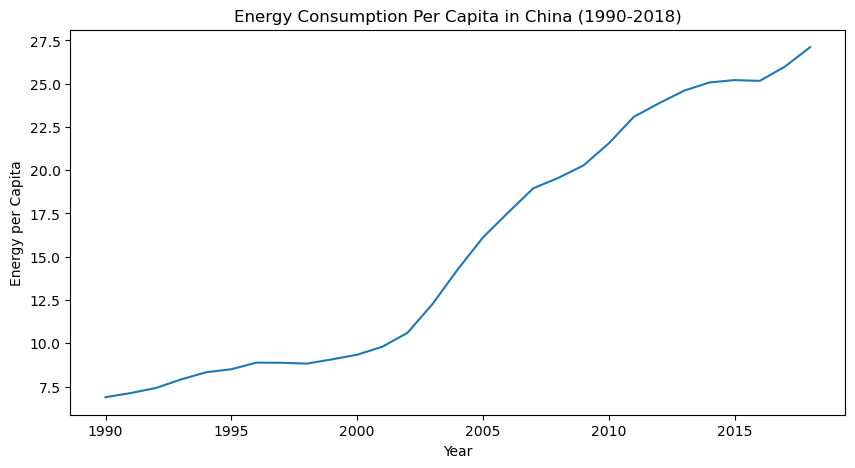

In [29]:
china_data = df_2[df_2["country"] == "China"]

plt.figure(figsize=(10,5))
plt.plot(china_data["year"], china_data["energy_per_capita"])

plt.title("Energy Consumption Per Capita in China (1990-2018)")
plt.xlabel("Year")
plt.ylabel("Energy per Capita")

plt.show()

### Energy Consumption Trend (China)

This line chart shows the change in energy consumption per capita in China from 1990 onwards.
Line plots are useful for identifying trends over time. The visualization helps reveal whether energy consumption is increasing as the country develops.

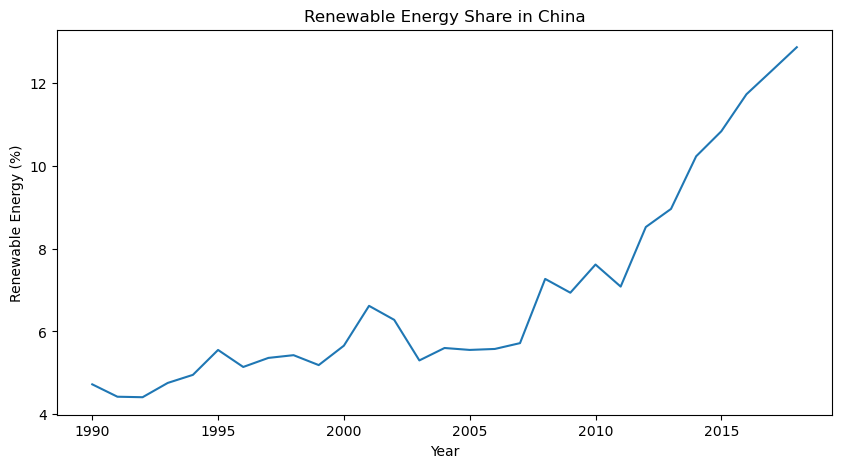

In [30]:
plt.figure(figsize=(10,5))

plt.plot(china_data["year"], china_data["renewable_share"])

plt.title("Renewable Energy Share in China")
plt.xlabel("Year")
plt.ylabel("Renewable Energy (%)")

plt.show()

### Renewable Energy Trend

This chart shows the percentage of energy consumption coming from renewable sources over time.
Analyzing this trend helps determine whether countries are transitioning toward cleaner energy sources.

<br>

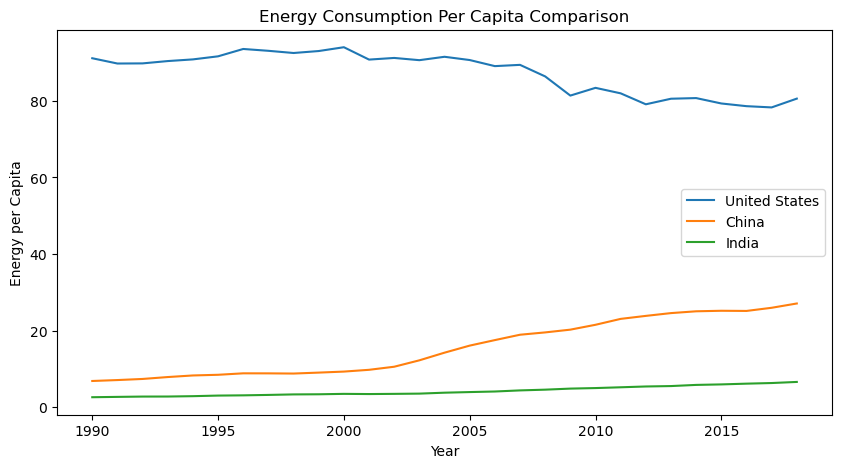

In [31]:
plt.figure(figsize=(10,5))

for country in ["United States","China","India"]:
    temp = df_2[df_2["country"] == country]
    plt.plot(temp["year"], temp["energy_per_capita"], label=country)

plt.title("Energy Consumption Per Capita Comparison")
plt.xlabel("Year")
plt.ylabel("Energy per Capita")
plt.legend()

plt.show()

### Energy Consumption Comparison Across Countries

This visualization compares energy consumption per capita for the United States, China, and India from 1990 to 2018.
- The United States consistently shows the highest energy consumption per person, reflecting its highly industrialized economy
and energy-intensive lifestyle.
- China shows a strong upward trend, which corresponds to its rapid economic growth and industrial expansion.
- India shows a gradual increase in energy consumption per capita, reflecting steady economic development and rising energy demand.

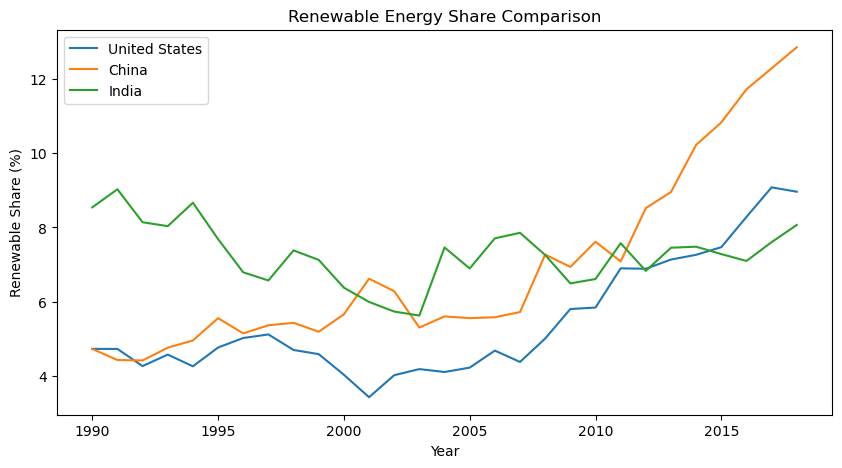

In [35]:
plt.figure(figsize=(10,5))

for country in ["United States","China","India"]:
    temp = df_2[df_2["country"] == country]
    plt.plot(temp["year"], temp["renewable_share"], label=country)

plt.title("Renewable Energy Share Comparison")
plt.xlabel("Year")
plt.ylabel("Renewable Share (%)")
plt.legend()

plt.show()

<br>

<br>

## Section 6: Decade-Level Analysis
In this section, we create a 'Decade' column to group our data into 10-year blocks. This helps us observe structural
economic shifts and long-term energy growth patterns across the 1990s, 2000s, and 2010s.

<br>

In [36]:
df_2['decade'] = (df_2['year'] // 10) * 10

In [37]:
df_2[['year','decade']].head(10)

,year,decade
4373,1990,1990
4374,1991,1990
4375,1992,1990
4376,1993,1990
4377,1994,1990
4378,1995,1990
4379,1996,1990
4380,1997,1990
4381,1998,1990
4382,1999,1990


In [38]:
decade_avg = df_2.groupby(['country','decade'])['primary_energy_consumption'].mean()

decade_avg

country        decade
China          1990       9918.388700
               2000      19448.144800
               2010      34119.689333
India          1990       2895.025000
               2000       4596.342800
               2010       7608.903889
United States  1990      24163.284500
               2000      26421.679900
               2010      25833.769778
Name: primary_energy_consumption, dtype: float64

In [39]:
decade_avg = decade_avg.reset_index()

decade_avg

,country,decade,primary_energy_consumption
0,China,1990,9918.388700
1,China,2000,19448.144800
2,China,2010,34119.689333
3,India,1990,2895.025000
4,India,2000,4596.342800
5,India,2010,7608.903889
6,United States,1990,24163.284500
7,United States,2000,26421.679900
8,United States,2010,25833.769778


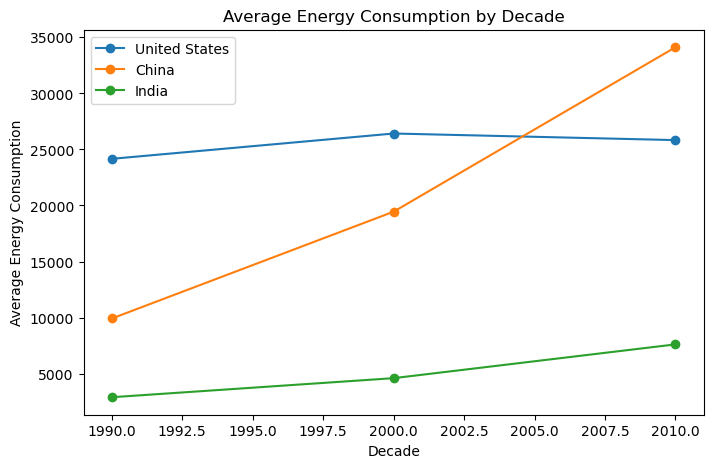

In [40]:
plt.figure(figsize=(8,5))

for country in ["United States","China","India"]:
    temp = decade_avg[decade_avg['country'] == country]
    plt.plot(temp['decade'], temp['primary_energy_consumption'], marker='o', label=country)

plt.xlabel("Decade")
plt.ylabel("Average Energy Consumption")
plt.title("Average Energy Consumption by Decade")

plt.legend()

plt.show()

<br>

<br>

## Statistical Analysis of CO₂ Emissions

To better understand the distribution of CO₂ emissions, we compute several statistical metrics.
• **Mean** represents the average emission level.  
• **Median** indicates the central value of the data.  
• **Standard Deviation** shows how widely emissions vary across observations.  
• **90th Percentile** helps identify the threshold for the top 10% highest emission observations.

These statistics help summarize overall emission patterns in the dataset.

<br>

In [45]:
mean_emissions = np.nanmean(df_2['greenhouse_gas_emissions'])
median_emissions = np.nanmedian(df_2['greenhouse_gas_emissions'])
std_emissions = np.nanstd(df_2['greenhouse_gas_emissions'])

mean_emissions, median_emissions, std_emissions

(np.float64(1693.742456140351),
 np.float64(1828.25),
 np.float64(989.7426252744676))

In [46]:
top_emitters_threshold = np.nanpercentile(df_2['greenhouse_gas_emissions'], 90)

top_emitters_threshold

np.float64(3275.636)

In [47]:
print("Mean Emissions:", mean_emissions)
print("Median Emissions:", median_emissions)
print("Standard Deviation:", std_emissions)
print("90th Percentile:", top_emitters_threshold)

Mean Emissions: 1693.742456140351
Median Emissions: 1828.25
Standard Deviation: 989.7426252744676
90th Percentile: 3275.636


<br>

<br>

##  Correlation Analysis


<br>

In [49]:
corr_matrix = df_2[['gdp','population','primary_energy_consumption','greenhouse_gas_emissions']].corr()

corr_matrix

,gdp,population,primary_energy_consumption,greenhouse_gas_emissions
gdp,1.000000,-0.440949,0.938055,0.839525
population,-0.440949,1.000000,-0.369144,-0.068471
primary_energy_consumption,0.938055,-0.369144,1.000000,0.958563
greenhouse_gas_emissions,0.839525,-0.068471,0.958563,1.000000


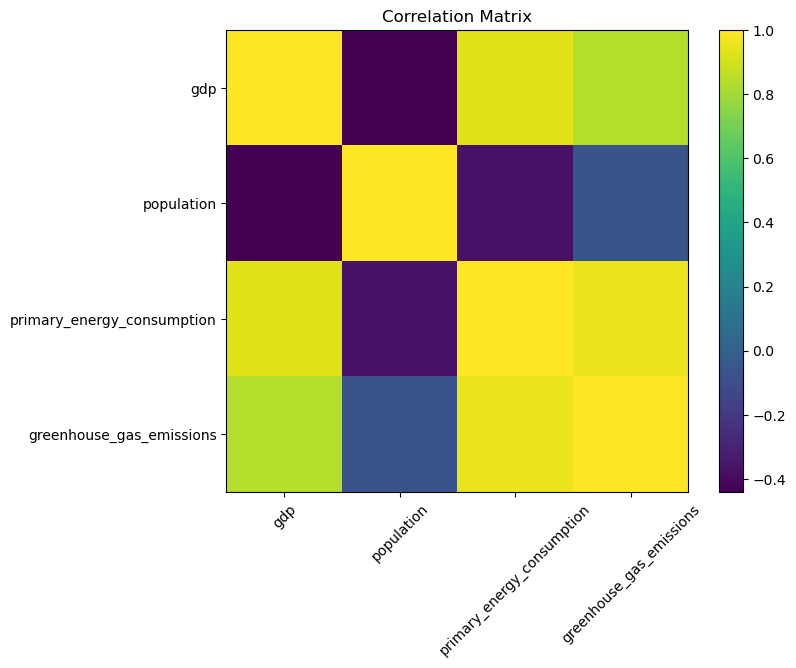

In [50]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

<br>

Correlation analysis measures how strongly variables move together.
The correlation matrix was calculated for key variables including GDP, population, energy consumption, and greenhouse gas emissions.
Strong positive correlations indicate that as one variable increases, the other tends to increase as well.

This analysis helps identify important relationships between economic growth, energy usage, and environmental impact.

<br>

## GDP vs Greenhouse Gas Emissions

<br>

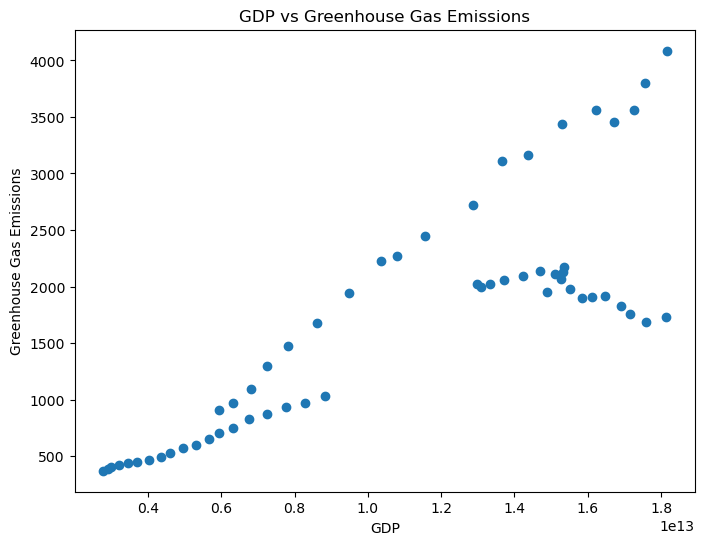

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(df_2['gdp'], df_2['greenhouse_gas_emissions'])

plt.xlabel("GDP")
plt.ylabel("Greenhouse Gas Emissions")

plt.title("GDP vs Greenhouse Gas Emissions")

plt.show()

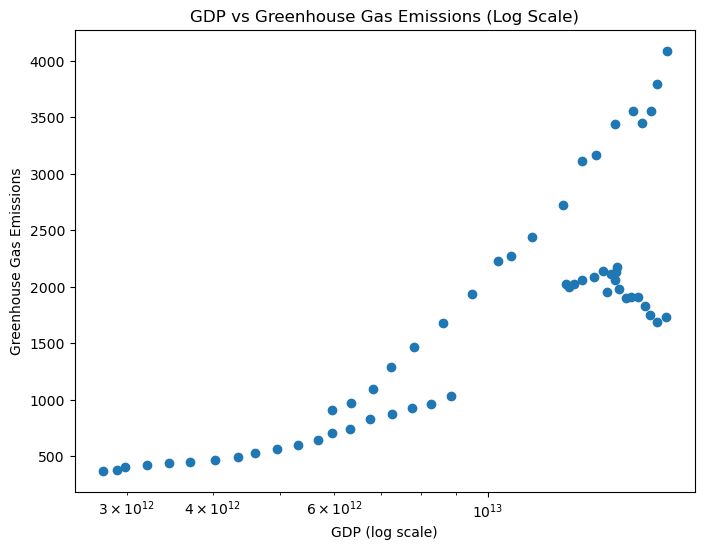

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(df_2['gdp'], df_2['greenhouse_gas_emissions'])

plt.xscale('log')

plt.xlabel("GDP (log scale)")
plt.ylabel("Greenhouse Gas Emissions")

plt.title("GDP vs Greenhouse Gas Emissions (Log Scale)")

plt.show()

A scatter plot was used to examine the relationship between economic output (GDP) and greenhouse gas emissions.
Each point represents a country-year observation.The visualization suggests a positive relationship between GDP
and emissions, meaning that countries with larger economies tend to produce higher levels of greenhouse gases.

A logarithmic scale was applied to GDP to better visualize the distribution of countries with very different economic sizes.

<br>

<br>

## Key Findings and Conclusion

This project analyzed the relationship between economic activity, energy consumption, and greenhouse gas emissions using a global energy dataset.

### Key Findings

1. **Economic Growth and Energy Consumption**

   The analysis shows a strong positive correlation between GDP and primary energy consumption. Countries with larger economies tend to require more energy to support industrial production, transportation, and infrastructure.

2. **Energy Consumption and Emissions**

   A very strong correlation was observed between energy consumption and greenhouse gas emissions. This suggests that increased energy demand, particularly from fossil fuels, leads directly to higher emissions.

3. **GDP and Environmental Impact**

   The scatter plot analysis indicates a positive relationship between GDP and greenhouse gas emissions. While economic growth improves living standards, it also contributes to environmental pressures.

4. **Population Influence**

   Population showed weaker correlations with energy consumption and emissions compared to GDP. This suggests that economic activity and energy intensity are more important drivers of emissions than population size alone.

### Conclusion

The results highlight the strong link between economic development, energy consumption, and environmental impact. As global economies grow, energy demand and greenhouse gas emissions also tend to increase.

The results suggest that economic growth remains closely linked to energy demand and emissions, highlighting the importance of transitioning toward renewable energy sources to achieve sustainable development.